# W02 KSCP Financial Analysis

**Prepared by:** Yincheng Zhang  
**Company:** Knightscope, Inc. (NASDAQ: KSCP)  
**Analysis Period:** Q1 2025–Q2 2026  

## Business Objective

This notebook analyzes Knightscope’s recent financial performance to support the Week 2 Market Intelligence Report. The analysis focuses on revenue growth, gross margin, operating expenses, cash runway, and disclosed deployment metrics.

## Analysis Scope

1. Examine quarterly revenue trends over the latest six reporting periods.
2. Calculate and visualize quarterly gross margin.
3. Analyze FY2025 operating expenses as a percentage of revenue.
4. Estimate cash runway using recent quarterly operating cash burn.
5. Calculate revenue per deployed unit if sufficient deployment data are disclosed.

All monetary values are presented in USD millions unless otherwise stated. Financial data and source information are obtained from the SEC filings documented in `W02_Market_Data.xlsx`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display


# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)


# Visualization settings
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 120

In [2]:
#%pip install openpyxl

In [3]:
DATA_PATH = Path("W02_Market_Data.xlsx")
SHEET_NAME = "KSCP_Financials"


if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Data file not found: {DATA_PATH.resolve()}\n"
        "Place the Excel file in the same folder as this notebook."
    )


excel_file = pd.ExcelFile(DATA_PATH)

print("Available worksheets:")
print(excel_file.sheet_names)

Available worksheets:
['Company_Comparison', 'KSCP_Financials', 'Market_Sizing']


## Load and Reshape KSCP Financial Data

The `KSCP_Financials` worksheet stores financial metrics in rows and reporting periods in columns. The data are transposed so that each row represents one quarterly period, which is more suitable for time-series analysis and visualization.

In [4]:
kscp_raw = pd.read_excel(
    DATA_PATH,
    sheet_name=SHEET_NAME
)

print(f"Raw dataset shape: {kscp_raw.shape}")
display(kscp_raw)

Raw dataset shape: (13, 7)


,Period,Q1 2025,Q2 2025,Q3 2025,Q4 2025,Q1 2026,Q2 2026
0,Revenue,2.9170,2.7490,3.1310,2.5380,6.0160,9.0240
1,Cost of Revenue,3.5850,3.6670,4.7010,4.1570,5.5510,8.3600
2,Gross Profit,-0.6680,-0.9180,-1.5700,-1.6190,0.4650,0.6640
3,Gross Margin,-0.2290,-0.3339,-0.5014,-0.6379,0.0773,0.0736
4,R&D,2.1250,2.0990,3.7730,4.4890,4.6800,6.0410
5,"Sales, General and Administrative",4.0350,3.2400,4.1650,5.1790,6.1120,7.7160
6,Cash & Cash Equivalents,12.6610,8.2110,20.3890,20.5660,11.4010,8.1600
7,Net Cash Burn,6.3750,5.4900,7.8700,10.6100,11.6040,NaN
8,Units Deployed,NaN,NaN,NaN,NaN,NaN,NaN
9,Source Filing,Knightscope Q1 2025 Form 10-Q,Knightscope Q2 2025 Form 10-Q,Knightscope Q3 2025 Form 10-Q,Knightscope FY2025 Form 10-K + Q3 2025 Form 10-Q,"Knightscope Form 10-Q, quarter ended March 31,...","Knightscope Form 10-Q, quarter ended June 30, ..."


In [5]:
financials = (
    kscp_raw
    .set_index("Period")
    .T
    .rename_axis("Period")
    .reset_index()
    .rename(
        columns={
            "Sales, General and Administrative": "SG&A"
        }
    )
)


# Define the chronological order of reporting periods
period_order = [
    "Q1 2025",
    "Q2 2025",
    "Q3 2025",
    "Q4 2025",
    "Q1 2026",
    "Q2 2026"
]

financials["Period"] = pd.Categorical(
    financials["Period"],
    categories=period_order,
    ordered=True
)

financials = (
    financials
    .sort_values("Period")
    .reset_index(drop=True)
)

In [6]:
numeric_columns = [
    "Revenue",
    "Cost of Revenue",
    "Gross Profit",
    "Gross Margin",
    "R&D",
    "SG&A",
    "Cash & Cash Equivalents",
    "Net Cash Burn",
    "Units Deployed"
]


financials[numeric_columns] = financials[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)


# Remove the filing-type note from the Q4 2025 date before conversion
def format_filing_date(value):
    if pd.isna(value):
        return pd.NA

    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d")

    return str(value).strip()


financials["Filing Date"] = (
    financials["Filing Date"]
    .apply(format_filing_date)
)


print(f"Cleaned dataset shape: {financials.shape}")

display(
    financials[
        [
            "Period",
            "Revenue",
            "Cost of Revenue",
            "Gross Profit",
            "Gross Margin",
            "R&D",
            "SG&A",
            "Cash & Cash Equivalents",
            "Net Cash Burn"
        ]
    ]
)

Cleaned dataset shape: (6, 14)


Period,Period,Revenue,Cost of Revenue,Gross Profit,Gross Margin,R&D,SG&A,Cash & Cash Equivalents,Net Cash Burn
0,Q1 2025,2.9170,3.5850,-0.6680,-0.2290,2.1250,4.0350,12.6610,6.3750
1,Q2 2025,2.7490,3.6670,-0.9180,-0.3339,2.0990,3.2400,8.2110,5.4900
2,Q3 2025,3.1310,4.7010,-1.5700,-0.5014,3.7730,4.1650,20.3890,7.8700
3,Q4 2025,2.5380,4.1570,-1.6190,-0.6379,4.4890,5.1790,20.5660,10.6100
4,Q1 2026,6.0160,5.5510,0.4650,0.0773,4.6800,6.1120,11.4010,11.6040
5,Q2 2026,9.0240,8.3600,0.6640,0.0736,6.0410,7.7160,8.1600,NaN


In [7]:
required_columns = [
    "Period",
    "Revenue",
    "Cost of Revenue",
    "Gross Profit",
    "Gross Margin",
    "R&D",
    "SG&A",
    "Cash & Cash Equivalents",
    "Net Cash Burn",
    "Source Filing",
    "Filing Date",
    "Source URL"
]


missing_columns = [
    column
    for column in required_columns
    if column not in financials.columns
]


assert not missing_columns, (
    f"Missing required columns: {missing_columns}"
)

assert financials["Period"].notna().all(), (
    "One or more reporting periods are missing."
)

assert not financials["Period"].duplicated().any(), (
    "Duplicate reporting periods were found."
)

assert financials["Revenue"].notna().all(), (
    "Revenue contains missing values."
)

assert (financials["Revenue"] > 0).all(), (
    "Revenue must be greater than zero."
)


print("Data quality checks passed.")
print(f"Reporting periods: {financials['Period'].nunique()}")
print(
    "Analysis range:",
    financials["Period"].iloc[0],
    "to",
    financials["Period"].iloc[-1]
)

Data quality checks passed.
Reporting periods: 6
Analysis range: Q1 2025 to Q2 2026


## Quarterly Revenue Trend

Quarterly revenue is analyzed across the six reporting periods from Q1 2025 through Q2 2026. Quarter-over-quarter and year-over-year growth rates are calculated to distinguish recent momentum from the longer-term comparison.

In [8]:
financials["Revenue QoQ Growth"] = (
    financials["Revenue"].pct_change()
)

financials["Revenue YoY Growth"] = (
    financials["Revenue"].pct_change(periods=4)
)


revenue_summary = financials[
    [
        "Period",
        "Revenue",
        "Revenue QoQ Growth",
        "Revenue YoY Growth"
    ]
].copy()


revenue_summary["Revenue QoQ Growth"] = (
    revenue_summary["Revenue QoQ Growth"]
    .map(lambda value: f"{value:.1%}" if pd.notna(value) else "N/A")
)

revenue_summary["Revenue YoY Growth"] = (
    revenue_summary["Revenue YoY Growth"]
    .map(lambda value: f"{value:.1%}" if pd.notna(value) else "N/A")
)


display(revenue_summary)

Period,Period,Revenue,Revenue QoQ Growth,Revenue YoY Growth
0,Q1 2025,2.9170,N/A,N/A
1,Q2 2025,2.7490,-5.8%,N/A
2,Q3 2025,3.1310,13.9%,N/A
3,Q4 2025,2.5380,-18.9%,N/A
4,Q1 2026,6.0160,137.0%,106.2%
5,Q2 2026,9.0240,50.0%,228.3%


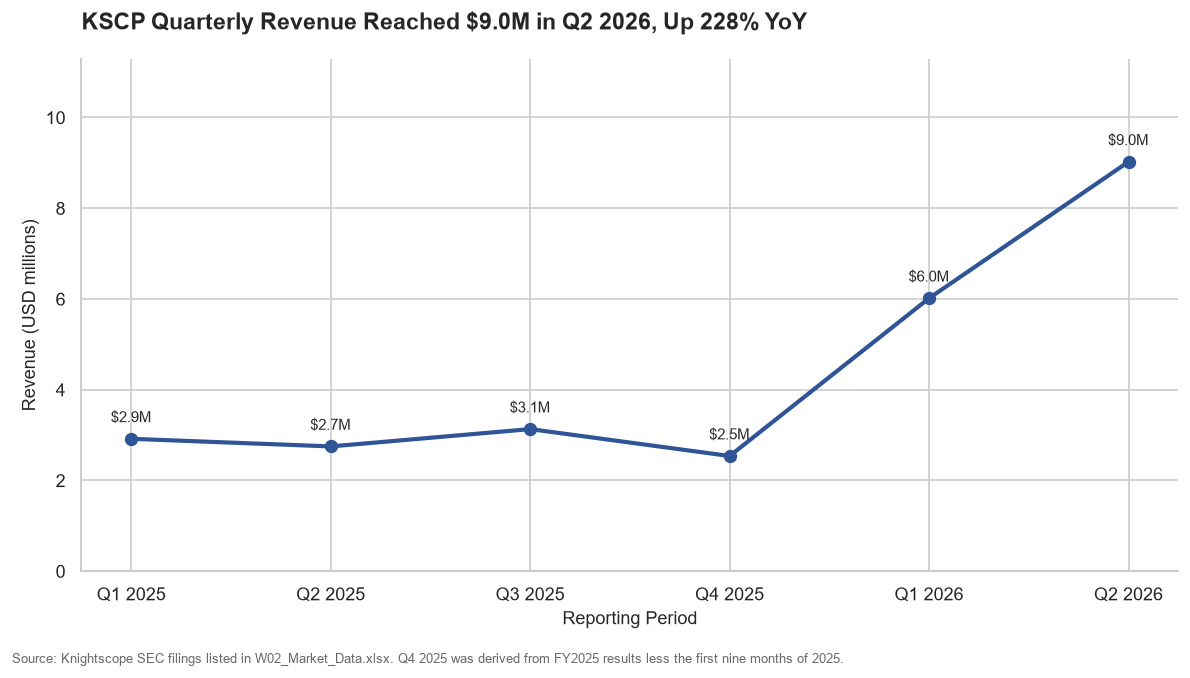

In [9]:
revenue_plot = financials.copy()

revenue_plot["Period Label"] = (
    revenue_plot["Period"].astype(str)
)


fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(
    revenue_plot["Period Label"],
    revenue_plot["Revenue"],
    color="#2F5597",
    linewidth=2.5,
    marker="o",
    markersize=7
)


# Add a value label to each quarterly observation
for period, revenue in zip(
    revenue_plot["Period Label"],
    revenue_plot["Revenue"]
):
    ax.annotate(
        f"${revenue:.1f}M",
        xy=(period, revenue),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )


ax.set_title(
    "KSCP Quarterly Revenue Reached $9.0M in Q2 2026, Up 228% YoY",
    loc="left",
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Reporting Period")
ax.set_ylabel("Revenue (USD millions)")
ax.set_ylim(0, revenue_plot["Revenue"].max() * 1.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    -0.02,
    "Source: Knightscope SEC filings listed in W02_Market_Data.xlsx. "
    "Q4 2025 was derived from FY2025 results less the first nine months of 2025.",
    ha="left",
    fontsize=8,
    color="dimgray"
)

plt.tight_layout()
plt.show()

### Revenue Interpretation

KSCP’s quarterly revenue remained between approximately $2.5 million and $3.1 million during 2025 before increasing to $6.0 million in Q1 2026 and $9.0 million in Q2 2026. Q2 2026 revenue increased 50.0% from the previous quarter and 228.3% from Q2 2025.

However, the increase should not be interpreted as entirely organic growth. Knightscope completed its acquisition of Knightscope Security Force in February 2026, and the acquired security-services business contributed to revenue beginning in Q1 2026. The revenue trend therefore reflects both business growth and a change in the company’s operating scope.

## Gross Margin Trend

Gross margin measures the percentage of revenue remaining after deducting the direct cost of generating that revenue.

The formula used in this analysis is:

$$
\text{Gross Margin}
=
\frac{\text{Revenue} - \text{Cost of Revenue}}
{\text{Revenue}}
$$

The calculated values are compared with the gross margin values stored in the source workbook. Small differences may occur because the workbook values are rounded.

In [10]:
financials["Calculated Gross Profit"] = (
    financials["Revenue"]
    - financials["Cost of Revenue"]
)

financials["Calculated Gross Margin"] = (
    financials["Calculated Gross Profit"]
    / financials["Revenue"]
)

financials["Gross Margin Difference"] = (
    financials["Calculated Gross Margin"]
    - financials["Gross Margin"]
)


gross_margin_check = financials[
    [
        "Period",
        "Revenue",
        "Cost of Revenue",
        "Calculated Gross Profit",
        "Gross Margin",
        "Calculated Gross Margin",
        "Gross Margin Difference"
    ]
].copy()


display(gross_margin_check)

Period,Period,Revenue,Cost of Revenue,Calculated Gross Profit,Gross Margin,Calculated Gross Margin,Gross Margin Difference
0,Q1 2025,2.9170,3.5850,-0.6680,-0.2290,-0.2290,-0.0000
1,Q2 2025,2.7490,3.6670,-0.9180,-0.3339,-0.3339,-0.0000
2,Q3 2025,3.1310,4.7010,-1.5700,-0.5014,-0.5014,-0.0000
3,Q4 2025,2.5380,4.1570,-1.6190,-0.6379,-0.6379,-0.0000
4,Q1 2026,6.0160,5.5510,0.4650,0.0773,0.0773,-0.0000
5,Q2 2026,9.0240,8.3600,0.6640,0.0736,0.0736,-0.0000


In [11]:
maximum_difference = (
    financials["Gross Margin Difference"]
    .abs()
    .max()
)


assert np.allclose(
    financials["Calculated Gross Margin"],
    financials["Gross Margin"],
    atol=0.0001
), "Calculated gross margin does not match the source data."


print("Gross margin validation passed.")
print(f"Maximum difference: {maximum_difference:.6f}")

Gross margin validation passed.
Maximum difference: 0.000040


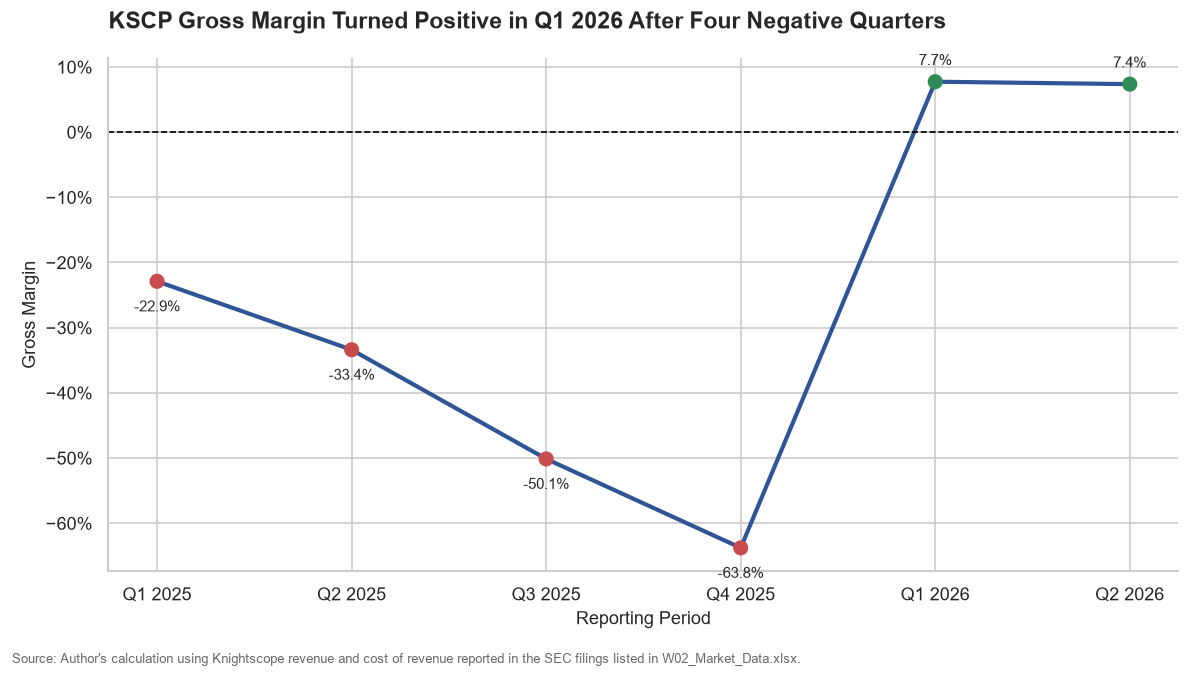

In [12]:
from matplotlib.ticker import PercentFormatter


gross_margin_plot = financials.copy()

gross_margin_plot["Period Label"] = (
    gross_margin_plot["Period"].astype(str)
)


point_colors = np.where(
    gross_margin_plot["Calculated Gross Margin"] >= 0,
    "#2E8B57",
    "#C94C4C"
)


fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(
    gross_margin_plot["Period Label"],
    gross_margin_plot["Calculated Gross Margin"],
    color="#2F5597",
    linewidth=2.5
)

ax.scatter(
    gross_margin_plot["Period Label"],
    gross_margin_plot["Calculated Gross Margin"],
    color=point_colors,
    s=65,
    zorder=3
)


# Add percentage labels
for period, margin in zip(
    gross_margin_plot["Period Label"],
    gross_margin_plot["Calculated Gross Margin"]
):
    label_offset = 10 if margin >= 0 else -18

    ax.annotate(
        f"{margin:.1%}",
        xy=(period, margin),
        xytext=(0, label_offset),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )


# Highlight the break-even level
ax.axhline(
    y=0,
    color="black",
    linewidth=1,
    linestyle="--"
)


ax.set_title(
    "KSCP Gross Margin Turned Positive in Q1 2026 "
    "After Four Negative Quarters",
    loc="left",
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Reporting Period")
ax.set_ylabel("Gross Margin")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    -0.02,
    "Source: Author's calculation using Knightscope revenue and cost of "
    "revenue reported in the SEC filings listed in W02_Market_Data.xlsx.",
    ha="left",
    fontsize=8,
    color="dimgray"
)

plt.tight_layout()
plt.show()

### Gross Margin Interpretation

KSCP reported negative gross margins throughout 2025, with the margin declining from −22.9% in Q1 2025 to −63.8% in Q4 2025. This indicates that direct cost of revenue exceeded revenue during each of those quarters.

Gross margin turned positive in Q1 2026 and remained positive in Q2 2026. The Q2 2026 margin of 7.4% represented an improvement of approximately 40.8 percentage points from −33.4% in Q2 2025. However, the margin decreased slightly from 7.7% in Q1 2026, suggesting that the company had not yet established a consistently expanding margin.

## FY2025 Operating Expense Decomposition

Operating expenses are evaluated for FY2025, the most recent complete annual reporting period in the dataset. Each expense category is presented as a percentage of FY2025 revenue.

The source data combine Sales and Marketing with General and Administrative expenses into one SG&A category. Therefore, these expenses cannot be separated without introducing unsupported estimates.

In [13]:
fy2025_periods = [
    "Q1 2025",
    "Q2 2025",
    "Q3 2025",
    "Q4 2025"
]


fy2025_data = financials[
    financials["Period"].isin(fy2025_periods)
].copy()


fy2025_revenue = fy2025_data["Revenue"].sum()
fy2025_rd = fy2025_data["R&D"].sum()
fy2025_sga = fy2025_data["SG&A"].sum()


opex_summary = pd.DataFrame(
    {
        "Expense Category": [
            "Research & Development",
            "SG&A"
        ],
        "Amount": [
            fy2025_rd,
            fy2025_sga
        ]
    }
)


opex_summary["Percentage of Revenue"] = (
    opex_summary["Amount"]
    / fy2025_revenue
)


combined_opex_percentage = (
    opex_summary["Amount"].sum()
    / fy2025_revenue
)


print(f"FY2025 Revenue: ${fy2025_revenue:.3f}M")
print(
    "Combined R&D and SG&A as a percentage of revenue: "
    f"{combined_opex_percentage:.1%}"
)

display(
    opex_summary.style.format(
        {
            "Amount": "${:,.3f}M",
            "Percentage of Revenue": "{:.1%}"
        }
    )
)

FY2025 Revenue: $11.335M
Combined R&D and SG&A as a percentage of revenue: 256.8%


,Expense Category,Amount,Percentage of Revenue
0,Research & Development,$12.486M,110.2%
1,SG&A,$16.619M,146.6%


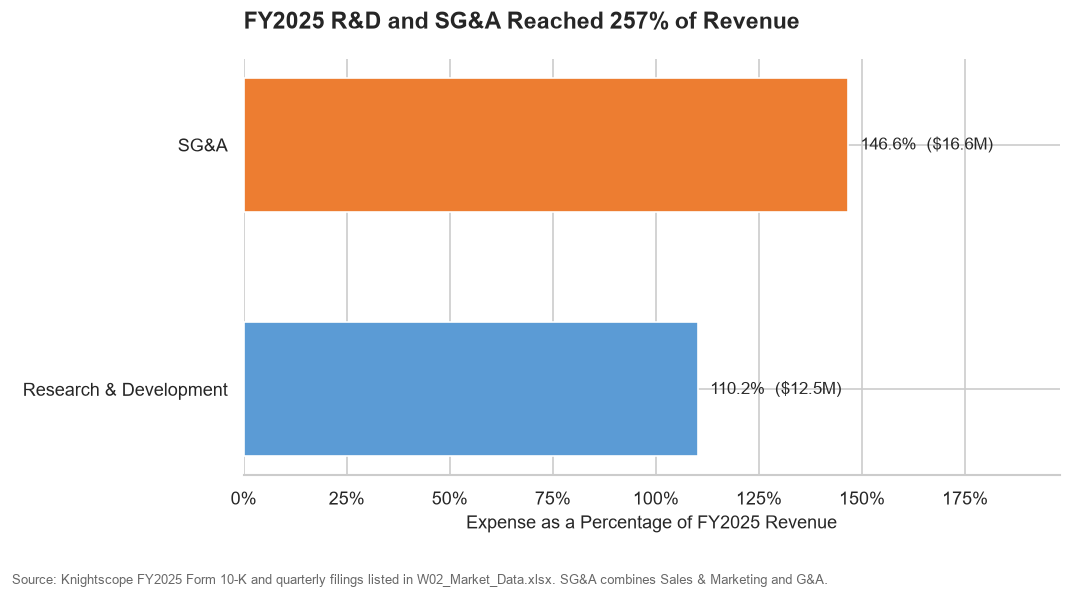

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))


bars = ax.barh(
    opex_summary["Expense Category"],
    opex_summary["Percentage of Revenue"],
    color=["#5B9BD5", "#ED7D31"],
    height=0.55
)


for bar, percentage, amount in zip(
    bars,
    opex_summary["Percentage of Revenue"],
    opex_summary["Amount"]
):
    ax.text(
        percentage + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f"{percentage:.1%}  (${amount:.1f}M)",
        va="center",
        fontsize=10
    )


ax.set_title(
    "FY2025 R&D and SG&A Reached 257% of Revenue",
    loc="left",
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Expense as a Percentage of FY2025 Revenue")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_xlim(
    0,
    opex_summary["Percentage of Revenue"].max() * 1.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

fig.text(
    0.01,
    0.01,
    "Source: Knightscope FY2025 Form 10-K and quarterly filings listed in "
    "W02_Market_Data.xlsx. SG&A combines Sales & Marketing and G&A.",
    ha="left",
    fontsize=8,
    color="dimgray"
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

### Operating Expense Interpretation

KSCP generated $11.3 million of revenue in FY2025 while spending $12.5 million on R&D and $16.6 million on SG&A. R&D represented approximately 110.2% of annual revenue, while SG&A represented approximately 146.6%.

Together, the two expense categories reached approximately 256.8% of revenue. This cost structure indicates that operating expenses remained substantially above the company’s revenue base, creating continued pressure on profitability and liquidity.

## Cash Runway Estimate

Cash runway estimates how long the company could continue operating if its recent cash consumption remained unchanged and no additional financing were raised.

The formula is:

$$
\text{Cash Runway}
=
\frac{\text{Latest Cash Balance}}
{\text{Average Quarterly Cash Burn}}
$$
The Q2 2026 quarterly cash burn is derived by subtracting Q1 2026 operating cash used from operating cash used during the first six months of 2026.

$$
\$23.099\text{M} - \$11.604\text{M}
=
\$11.495\text{M}
$$

The analysis uses the average cash burn from the latest four quarters to reduce dependence on a single quarterly observation.

In [15]:
# Amounts are in USD millions.
# H1 2026 operating cash used comes from the Q2 2026 Form 10-Q.

h1_2026_operating_cash_used = 23.099

q1_2026_operating_cash_used = financials.loc[
    financials["Period"] == "Q1 2026",
    "Net Cash Burn"
].iloc[0]


q2_2026_cash_burn = (
    h1_2026_operating_cash_used
    - q1_2026_operating_cash_used
)


# Preserve the original Excel column and create a separate analysis column.
financials["Quarterly Cash Burn"] = (
    financials["Net Cash Burn"].copy()
)

financials.loc[
    financials["Period"] == "Q2 2026",
    "Quarterly Cash Burn"
] = q2_2026_cash_burn


print(
    "Derived Q2 2026 quarterly cash burn: "
    f"${q2_2026_cash_burn:.3f}M"
)

Derived Q2 2026 quarterly cash burn: $11.495M


In [16]:
latest_four_quarters = financials.tail(4).copy()

average_quarterly_cash_burn = (
    latest_four_quarters["Quarterly Cash Burn"].mean()
)

latest_cash_balance = financials.loc[
    financials["Period"] == "Q2 2026",
    "Cash & Cash Equivalents"
].iloc[0]


cash_runway_quarters = (
    latest_cash_balance
    / average_quarterly_cash_burn
)

cash_runway_months = cash_runway_quarters * 3


cash_runway_summary = pd.DataFrame(
    {
        "Metric": [
            "Latest cash balance",
            "Average quarterly cash burn",
            "Estimated cash runway",
            "Estimated cash runway"
        ],
        "Value": [
            latest_cash_balance,
            average_quarterly_cash_burn,
            cash_runway_quarters,
            cash_runway_months
        ],
        "Unit": [
            "USD millions",
            "USD millions per quarter",
            "Quarters",
            "Months"
        ]
    }
)


display(
    cash_runway_summary.style.format(
        {
            "Value": "{:,.2f}"
        }
    )
)

,Metric,Value,Unit
0,Latest cash balance,8.16,USD millions
1,Average quarterly cash burn,10.39,USD millions per quarter
2,Estimated cash runway,0.79,Quarters
3,Estimated cash runway,2.36,Months


In [17]:
display(
    latest_four_quarters[
        [
            "Period",
            "Cash & Cash Equivalents",
            "Quarterly Cash Burn"
        ]
    ].style.format(
        {
            "Cash & Cash Equivalents": "${:,.3f}M",
            "Quarterly Cash Burn": "${:,.3f}M"
        }
    )
)

Period,Period,Cash & Cash Equivalents,Quarterly Cash Burn
2,Q3 2025,$20.389M,$7.870M
3,Q4 2025,$20.566M,$10.610M
4,Q1 2026,$11.401M,$11.604M
5,Q2 2026,$8.160M,$11.495M


### Cash Runway Interpretation

KSCP held approximately $8.2 million in cash and cash equivalents at the end of Q2 2026. Average quarterly operating cash burn over the latest four quarters was approximately $10.4 million.

Dividing the latest cash balance by average quarterly cash burn produces an estimated runway of approximately 0.8 quarters, or 2.4 months. This estimate indicates a significant near-term liquidity risk if the recent rate of cash consumption continues.

The estimate is a simplified analytical measure. It excludes potential financing, changes in working capital, non-operating cash flows, and management actions that could reduce future spending.

## Revenue per Deployed Unit

Revenue per deployed unit would normally be calculated as:

$$
\text{Revenue per Deployed Unit}
=
\frac{\text{Quarterly Revenue}}
{\text{Units Deployed}}
$$

However, Knightscope did not disclose a comparable quarterly count of deployed Autonomous Security Robots for the periods included in this analysis. The company’s disclosure of more than 10,000 machines, stationary devices, and security agents represents a broader network measure and should not be interpreted as the number of deployed ASRs.

In [18]:
unit_data_available = (
    financials["Units Deployed"].notna().any()
)


if unit_data_available:
    financials["Revenue per Deployed Unit"] = (
        financials["Revenue"]
        / financials["Units Deployed"]
    )

    display(
        financials[
            [
                "Period",
                "Revenue",
                "Units Deployed",
                "Revenue per Deployed Unit"
            ]
        ]
    )

else:
    print(
        "Revenue per deployed unit cannot be calculated because "
        "comparable quarterly deployment counts were not disclosed."
    )

Revenue per deployed unit cannot be calculated because comparable quarterly deployment counts were not disclosed.


## Key Metrics Summary

The following table consolidates the main financial indicators calculated in this notebook.

In [19]:
q2_2025 = financials.loc[
    financials["Period"] == "Q2 2025"
].iloc[0]

q2_2026 = financials.loc[
    financials["Period"] == "Q2 2026"
].iloc[0]


q2_2026_yoy_growth = (
    q2_2026["Revenue"]
    / q2_2025["Revenue"]
    - 1
)

gross_margin_improvement_pp = (
    q2_2026["Calculated Gross Margin"]
    - q2_2025["Calculated Gross Margin"]
) * 100


key_metrics = pd.DataFrame(
    {
        "Metric": [
            "Q2 2026 revenue",
            "Q2 2026 revenue growth",
            "Q2 2026 gross margin",
            "Year-over-year gross margin improvement",
            "FY2025 R&D and SG&A as percentage of revenue",
            "Estimated cash runway",
            "Estimated cash runway"
        ],
        "Value": [
            q2_2026["Revenue"],
            q2_2026_yoy_growth * 100,
            q2_2026["Calculated Gross Margin"] * 100,
            gross_margin_improvement_pp,
            combined_opex_percentage * 100,
            cash_runway_quarters,
            cash_runway_months
        ],
        "Unit": [
            "USD millions",
            "%",
            "%",
            "Percentage points",
            "% of revenue",
            "Quarters",
            "Months"
        ]
    }
)


display(
    key_metrics.style.format(
        {
            "Value": "{:,.2f}"
        }
    )
)

,Metric,Value,Unit
0,Q2 2026 revenue,9.02,USD millions
1,Q2 2026 revenue growth,228.26,%
2,Q2 2026 gross margin,7.36,%
3,Year-over-year gross margin improvement,40.75,Percentage points
4,FY2025 R&D and SG&A as percentage of revenue,256.77,% of revenue
5,Estimated cash runway,0.79,Quarters
6,Estimated cash runway,2.36,Months


## Key Findings

1. **Revenue accelerated after the acquisition.** Quarterly revenue reached $9.0 million in Q2 2026, representing an increase of approximately 228.3% from Q2 2025. A significant portion of this growth was associated with the acquisition of Knightscope Security Force, so the year-over-year comparison does not represent purely organic growth.

2. **Gross margin became positive but remained modest.** Gross margin improved from −33.4% in Q2 2025 to 7.4% in Q2 2026, an increase of approximately 40.8 percentage points. Nevertheless, the margin decreased slightly from 7.7% in Q1 2026.

3. **Operating expenses remained high relative to revenue.** FY2025 R&D and SG&A expenses represented approximately 256.8% of annual revenue. This cost structure remained a substantial barrier to operating profitability.

4. **Liquidity represented the most immediate financial risk.** KSCP held $8.2 million in cash at the end of Q2 2026, compared with an average quarterly operating cash burn of approximately $10.4 million. The resulting estimated cash runway was approximately 0.8 quarters, or 2.4 months, assuming no additional financing or major change in spending.

5. **Revenue per deployed unit could not be calculated reliably.** Comparable quarterly deployment counts were not disclosed. The company’s broader network disclosure includes robots, stationary devices, and security agents and therefore cannot be used as an ASR deployment count.

## Methodology and Limitations

- Financial amounts are presented in USD millions.
- Gross margin is calculated as revenue less cost of revenue, divided by revenue.
- Q4 2025 income-statement values are derived by subtracting the first nine months of 2025 from FY2025 totals.
- Q2 2026 operating cash burn is derived by subtracting Q1 2026 operating cash used from operating cash used during the first six months of 2026.
- Cash runway uses average quarterly cash burn from Q3 2025 through Q2 2026.
- The cash runway estimate excludes future equity financing, debt financing, working-capital changes, investing cash flows, and management cost reductions.
- The Knightscope Security Force acquisition reduced comparability between the 2025 and 2026 revenue periods.
- Sales and Marketing and General and Administrative expenses are combined as SG&A because the prepared dataset does not provide a reliable separate quarterly breakdown.
- Revenue per deployed unit is unavailable because comparable quarterly deployment data were not disclosed.

## Source Registry

The following table identifies the SEC filing used for each reporting period. The source metadata are retained directly from the input workbook to support traceability.

In [20]:
source_registry = financials[
    [
        "Period",
        "Source Filing",
        "Filing Date",
        "Source URL",
        "Notes"
    ]
].copy()


display(source_registry)

Period,Period,Source Filing,Filing Date,Source URL,Notes
0,Q1 2025,Knightscope Q1 2025 Form 10-Q,2025-05-14,https://www.sec.gov/Archives/edgar/data/160098...,SG&A combines reported Sales & Marketing and G...
1,Q2 2025,Knightscope Q2 2025 Form 10-Q,2025-08-12,https://www.sec.gov/Archives/edgar/data/160098...,Quarterly cash burn derived as H1 2025 operati...
2,Q3 2025,Knightscope Q3 2025 Form 10-Q,2025-11-12,https://www.sec.gov/Archives/edgar/data/160098...,Quarterly cash burn derived as 9M 2025 operati...
3,Q4 2025,Knightscope FY2025 Form 10-K + Q3 2025 Form 10-Q,27-Mar-26 (10-K); 12-Nov-25 (Q3 10-Q),https://www.sec.gov/Archives/edgar/data/160098...,Q4 income-statement and operating cash burn fi...
4,Q1 2026,"Knightscope Form 10-Q, quarter ended March 31,...",2026-05-15,https://www.sec.gov/Archives/edgar/data/160098...,Q1 2026 includes approximately $2.4M of Securi...
5,Q2 2026,"Knightscope Form 10-Q, quarter ended June 30, ...",2026-08-12,https://www.sec.gov/Archives/edgar/data/160098...,Revenue includes KSF acquisition contribution;...


## Final Reproducibility Check

The checks below confirm that the required periods, financial variables, source information, and calculated metrics are available before the notebook is finalized.

In [21]:
validation_checks = {
    "Six quarterly periods included":
        len(financials) == 6,

    "No duplicate reporting periods":
        not financials["Period"].duplicated().any(),

    "Revenue data complete":
        financials["Revenue"].notna().all(),

    "Gross margin calculation reconciles":
        np.allclose(
            financials["Calculated Gross Margin"],
            financials["Gross Margin"],
            atol=0.0001
        ),

    "Quarterly cash burn complete after derivation":
        financials["Quarterly Cash Burn"].notna().all(),

    "Source filing documented for every period":
        financials["Source Filing"].notna().all(),

    "Filing date documented for every period":
        financials["Filing Date"].notna().all(),

    "Source URL documented for every period":
        financials["Source URL"].notna().all()
}


validation_results = pd.DataFrame(
    {
        "Check": validation_checks.keys(),
        "Status": [
            "PASS" if result else "FAIL"
            for result in validation_checks.values()
        ]
    }
)


display(validation_results)


assert all(validation_checks.values()), (
    "One or more final validation checks failed."
)

print("All final validation checks passed.")

,Check,Status
0,Six quarterly periods included,PASS
1,No duplicate reporting periods,PASS
2,Revenue data complete,PASS
3,Gross margin calculation reconciles,PASS
4,Quarterly cash burn complete after derivation,PASS
5,Source filing documented for every period,PASS
6,Filing date documented for every period,PASS
7,Source URL documented for every period,PASS


All final validation checks passed.


## Conclusion

KSCP’s recent results show a meaningful improvement in revenue and gross margin following the Knightscope Security Force acquisition. However, the company’s operating-expense base and rate of cash consumption remain high relative to its current revenue and cash balance.

The central market-intelligence implication is that KSCP has demonstrated stronger commercial scale and positive gross margin, but its near-term financial sustainability remains dependent on margin improvement, expense control, and access to additional capital.